In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,f1_score
import pickle


In [ ]:
df = pd.read_csv("apple_stock.csv")

In [ ]:
print(df.info())
print(df.describe())
print(df.head())
print(df.tail(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2475 entries, 0 to 2474
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2475 non-null   object 
 1   Open       2475 non-null   float64
 2   High       2475 non-null   float64
 3   Low        2475 non-null   float64
 4   Close      2475 non-null   float64
 5   Adj Close  2475 non-null   float64
 6   Volume     2475 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 135.5+ KB
None
              Open         High          Low        Close    Adj Close  \
count  2475.000000  2475.000000  2475.000000  2475.000000  2475.000000   
mean     76.004968    76.845661    75.213720    76.064199    74.097124   
std      54.739063    55.389713    54.134658    54.787600    55.248195   
min      17.684999    17.911785    17.626785    17.849285    15.648315   
25%      29.592500    29.841249    29.371249    29.707500    27.131330   
50%      47.507500   

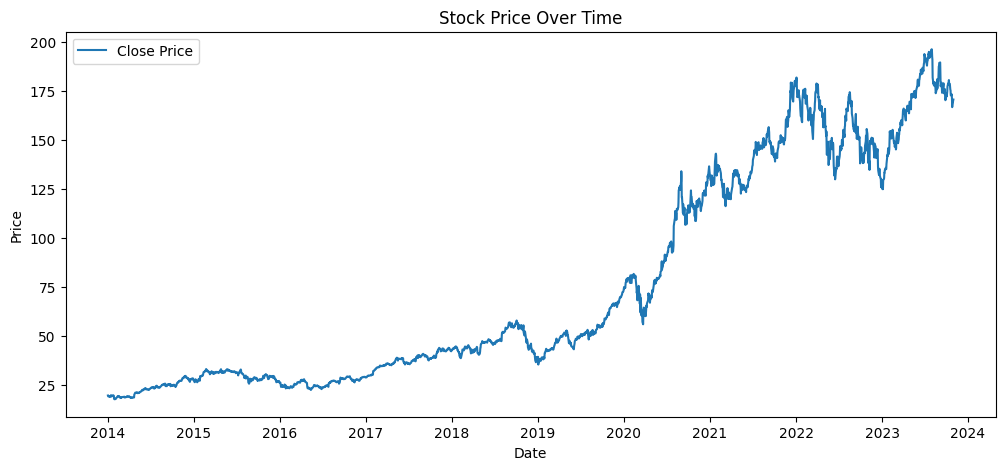

In [ ]:

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

plt.figure(figsize=(12,5))
plt.plot(df['Close'], label="Close Price")

plt.title("Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

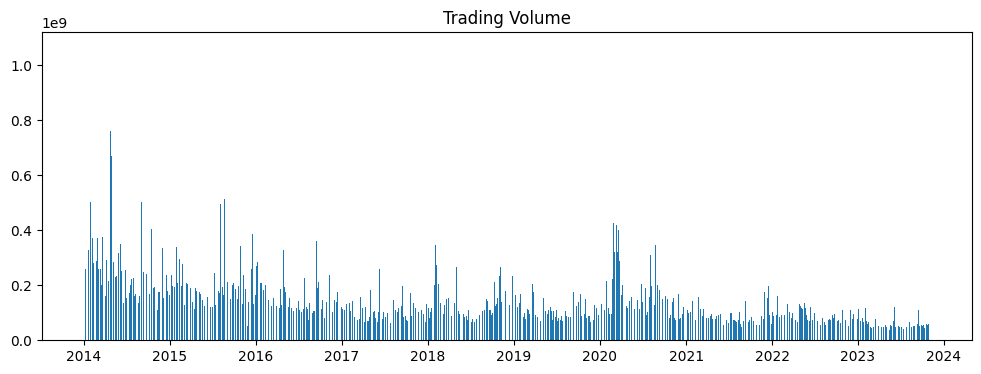

In [ ]:
plt.figure(figsize=(12,4))
plt.bar(df.index, df['Volume'])

plt.title("Trading Volume")
plt.show()


In [ ]:
df =df.drop_duplicates()

In [ ]:
df.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [ ]:
df.reset_index(drop=True, inplace=True)

In [ ]:
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
df = df.dropna()

In [ ]:
x = df[["Open","High","Low","Close","Adj Close","Volume"]]
y =df["Target"]

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model = LogisticRegression()

model.fit(x_train,y_train)

test_pred = model.predict(x_test)

print(test_pred)
print("classifiaction report",classification_report(test_pred,y_test))
print("classifiaction report",accuracy_score(test_pred,y_test))


[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=5,
    random_state=42

)

model.fit(x_train,y_train)

test_pred = model.predict(x_test)
print(test_pred)
print("accuracy score",accuracy_score(test_pred,y_test))

[1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 0 1 1 1
 1 1 1 1 1 0 0 1 1 0 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 1
 1 1 1 1 1 0 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1
 0 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1
 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0
 1 1 1 1 1 0 0 1 1 1 0 0 0 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 0 1 1 1 1 0
 1 1 0 0 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 0 1 1 0 1
 1 1 0 1 1 0 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1
 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0
 1 1 0 1 1 1 0 1 1 1 1 1 0 1 1 0 0 1 0 0 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1
 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 1 1 1 0
 1 1 0 1 1 1 0 1 1 1 1 1 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2475 entries, 0 to 2474
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2475 non-null   object 
 1   Open       2475 non-null   float64
 2   High       2475 non-null   float64
 3   Low        2475 non-null   float64
 4   Close      2475 non-null   float64
 5   Adj Close  2475 non-null   float64
 6   Volume     2475 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 135.5+ KB
None
              Open         High          Low        Close    Adj Close  \
count  2475.000000  2475.000000  2475.000000  2475.000000  2475.000000   
mean     76.004968    76.845661    75.213720    76.064199    74.097124   
std      54.739063    55.389713    54.134658    54.787600    55.248195   
min      17.684999    17.911785    17.626785    17.849285    15.648315   
25%      29.592500    29.841249    29.371249    29.707500    27.131330   
50%      47.507500   

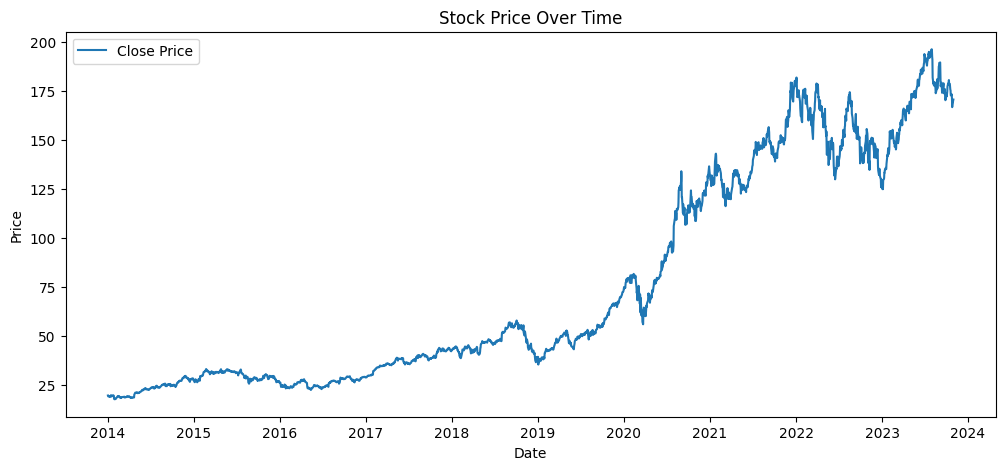

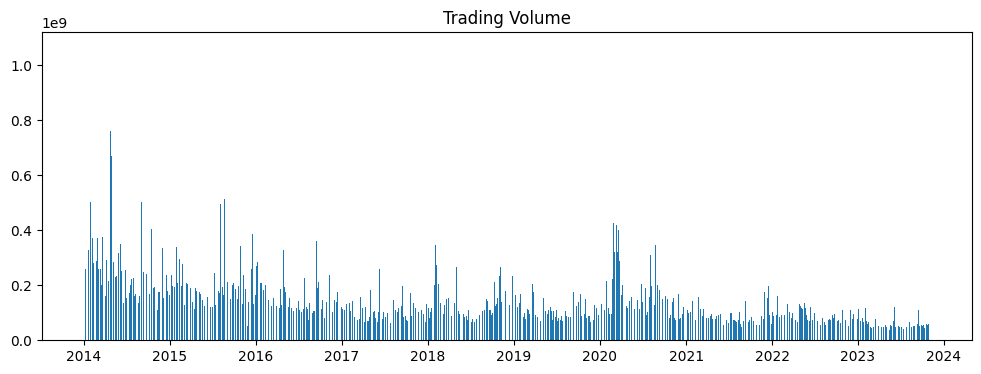

[0 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1 1 1 0 1 1
 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 0 1 1
 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 0 1 1 1 1 1 1
 1 1 1 0 1 1 1 0 1 1 1 0 1 1 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0 0
 1 0 0 1 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 1 0 1 1 1 1
 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 0 1 0 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1
 0 0 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 0 1 0 1 1 1 1 1 1 1 1
 1 1 1 1 0 1 1 1 1 1 0 1 0 1 1 1 1 1 0 0 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1
 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1
 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 0 0 

In [ ]:
# -*- coding: utf-8 -*-

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


df = pd.read_csv("apple_stock.csv")

print(df.info())
print(df.describe())
print(df.head())
print(df.tail())

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").drop_duplicates()
df.set_index("Date", inplace=True)

plt.figure(figsize=(12, 5))
plt.plot(df["Close"], label="Close Price")
plt.title("Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.bar(df.index, df["Volume"])
plt.title("Trading Volume")
plt.show()

# Better features for next-day movement prediction
df["Return_1D"] = df["Close"].pct_change()
df["Return_5D"] = df["Close"].pct_change(5)
df["SMA_5"] = df["Close"].rolling(5).mean()
df["SMA_10"] = df["Close"].rolling(10).mean()
df["SMA_Ratio"] = df["SMA_5"] / df["SMA_10"]
df["Volatility_5D"] = df["Return_1D"].rolling(5).std()
df["Volume_Change"] = df["Volume"].pct_change()

# Target: 1 if next day's close is higher, else 0
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

feature_columns = [
    "Return_1D",
    "Return_5D",
    "SMA_Ratio",
    "Volatility_5D",
    "Volume_Change",
]

df = df.dropna(subset=feature_columns + ["Target"]).copy()

X = df[feature_columns]
y = df["Target"]

# Time-series split instead of random split
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Logistic Regression
lr_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print(lr_pred)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Logistic Regression F1 Score:", f1_score(y_test, lr_pred))
print("Logistic Regression Report:\n", classification_report(y_test, lr_pred))

with open("lr_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print(rf_pred)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest F1 Score:", f1_score(y_test, rf_pred))
print("Random Forest Report:\n", classification_report(y_test, rf_pred))

with open("rf_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

